## Data lesson 5

Today we will learn about making functions and fitting models to data.

In [1]:
# Add import statements
import numpy as np
import matplotlib.pyplot as plt

#### **Functions in python**

We have already used many functions in python: those that are built-in like `print()` and `len()`, and those that are imported from modules like `np.log()` or `np.max()`.

These functions take some input value in parentheses, and provide some output in return.

Sometimes we wish to do a task in python and there isn't a function we can import to do the task.  In this case, we can define a new function ourselves.

This is useful for a couple of reasons.  First, we may want to do a task repeatedly and this allows us to reuse code throughout our program.

As we will see later, we can also use our custom functions for fitting data with models.

The basic syntax for defining a function is illustrated below.

In [3]:
def say_hello(num_greetings):
    greeting = "Hello!"*num_greetings
    return greeting

*Try calling the `say_hello()` function the way you would any other function.  It will accept any integer as an argument.*

In [6]:
# Add code here
say_hello(6)

'Hello!Hello!Hello!Hello!Hello!Hello!'

We now have an easy and flexible way to make a new string that says "Hello!" as many times as we wish.

Let's unpack the general structure of defining a function:
* `def` followed by the name of the function.  Like a variable, the function can be named (almost) anything.  In this case it is `say_hello`
* A set of parentheses to indicate the arguments accepted by the function (if any). In this case, the function accepts one argument: `num_greetings`.
* First line ends with a colon
* The next block of text is indented and represents the *executable* code.  This is the part that we want to have carried out each time we run the function.  In this case, it produces a string containing a number of `Hello!`'s.
* Each time the function is called, any argument variables take on whatever value was assigned to them during the function call.  In this case, `num_greetings` takes on an integer value defined when the function is called.
* The last line `return`s whatever output we are interested in.  A `return` statement is not required, but is usually useful if you want to do something based on the code you have executed.

Let's try another example. We'll make a function to convert between Farenheit and Celsius temperature scales.

*Below is the executable part of the code.  Create a new function `FtoC` that takes `temp_F` as an argument and returns `temp_C`.*

In [7]:
# Expand into a function
def FtoC(temp_F):
    temp_C = (temp_F-32)*5/9
    return temp_C

*Now try calling your function `FtoC` for a few different temperatures.*

In [10]:
# Add code here
FtoC(100)

37.77777777777778

Now we'll try an example where the function receives multiple arguments.  

*Create a function `add_two_numbers` to add two numbers `a` and `b` together and return the `sum`.*

In [12]:
# Expand into a function
def add_two_numbers(a,b):
    sum = a + b
    return sum

# Test out your new function here
add_two_numbers(100,16)

116

Functions can also return multiple values.

*Create a function to input a string and output new strings with `cats` and `dogs` added to the end of the original.*

In [13]:
# Expand into a function
def add_animals(word):
    word1 = word + 'cats'
    word2 = word + 'dogs'
    return word1, word2

add_animals('space')

('spacecats', 'spacedogs')

Ok, now one fully on your own: 
*Create a function corresponding to a linear relationship (y=mx+b).  It should accept as arguments an x value, slope, and intercept, and return a y value.*

In [20]:
# Add code here
def line(xvalue, slope, intercept):
    y=xvalue*slope+intercept
    return y

Let's test out your new function: 

*Make an array corresponding to x data points ranging from 1-10. Pass it to the function along with a slope & intercept to determine the y data points.*

*Make a plot of y vs x.*

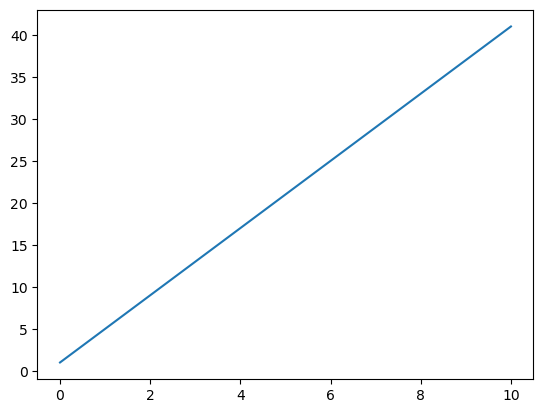

In [15]:
# Add code here
xdata = np.arange(0,11,1)
ydata = prediction(xdata, 4, 1)

plt.plot(xdata, ydata)

It is useful for many reasons to create your own functions in python.  It can save you time, keep things organized, and make your code shorter and easier to work with.

The rest of today, we will focus on another use case: using custom functions to fit data in python.

#### **Fitting data**

In lecture, we already talked about the idea of *least squares fitting*, in the context of fitting a line (y=mx+b) to a calibration curve.

This is a specific example of *optimization*: we try to find the set of parameters (m,b) that makes the line describe the measured points as best as possible.

In least squares fitting, the *metric* that we use to assesss goodness of fit is the sum of the squared errors.  The optimization problem is to minimize the squares of the deviations between the actual data and the output of an equation.

The module `scipy.optimize` within the `scipy` library contains many functions for this type of optimization problem.  Today we will use `optimize.curve_fit()`, which is a very flexible and popular least-squares fitter.

Below we import just the `curve_fit()` function from `scipy.optimize`.

In [16]:
from scipy.optimize import curve_fit

`curve_fit()` has a few required arguments:
* `func`, the python function describing the equation to be fitted to the data
* `xdata`, the independent variable that is being fitted
* `ydata`, the dependent variable that is being fitted

Let's try out curve_fit with some real data. 

*Load in the file `calibration_curve.txt` and store the data in new arrays for concentration & absorbance.*

In [18]:
# Add code here
data = np.genfromtxt('calibration_curve.txt')
concentration=data.T[0]
absorbance=data.T[1]

*Make a plot of concentration vs. absorbance*

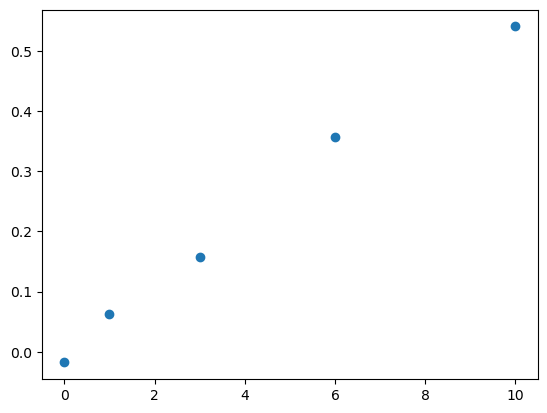

In [19]:
# Add code here
plt.scatter(concentration, absorbance)

Our data looks like it will be well described by a line y(x)=mx+b.

 We already have a line function defined above, but let's make sure it is in the right format.

* The first argument into the function *must* be the independent variable (x).  
* Any other arguments are *free parameters* that will be varied in order to fit the equation to the data.

Now we have everything we need to call `curve_fit()`. 

In [21]:
params, pcov = curve_fit(line, concentration, absorbance)
params

array([ 0.05583194, -0.00335361])

`curve_fit()` returns two arrays, which we have assigned to the variables `params` and `pcov`. 

The first array contains the optimal parameter values.  They are in the same order as the order of arguments in our fitting function: in this case slope then intercept.

*Compare the optimized slope & intercept to your plot above. Do they seem reasonable?*

It is often helpful to overplot the best-fit line with the measured data.

We can produce a line based on the optimized parameters by using the fitting function provided to `curve_fit()`.

Below we evaluate the function `line` at all of the concentrations (x values) of our measured data, using the slope & intercept determined from `curve_fit`. 

In [22]:
# assigning the best-fit parameters to variables for convenience
mm = params[0]
bb = params[1]

# calculating the best-fit line
y_fit = line(concentration, mm,bb)

*Make a scatter plot of the measured concentration vs. absorbance values.  Over-plot the concentration vs. best-fit line.*

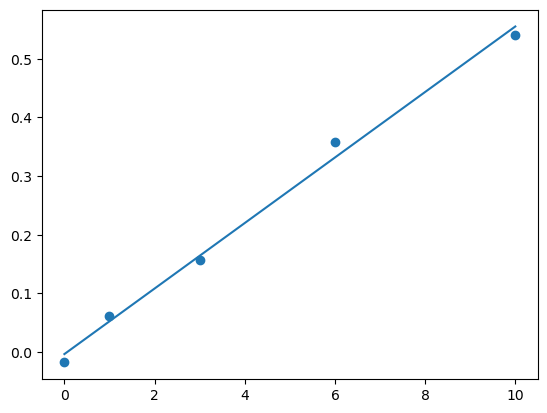

In [23]:
# Add code here
plt.scatter(concentration,absorbance)
plt.plot(concentration, y_fit)

Let's say we have measured an unknown sample with an absorbance equal to 0.27.  

We know that x = (y-b)/m

*Calculate the concentration using the best-fit slope & intercept.*

In [24]:
# Add code here
(0.27-bb)/mm

np.float64(4.8960076973246025)

The second array returned by `curve_fit()` is the covariance matrix.  If we diagonalize this we obtain the *one-standard-deviation errors* for each fit parameter.  

Don't worry if you don't know about diagonalizing matrices; you can just copy the code below and know that the result corresponds to the parameter uncertainties.

Knowing the uncertainty on slope & intercept allows us to propagate error in subsequent calculations!

In [25]:
errors = np.sqrt(np.diag(pcov))
print(errors)

[0.00249145 0.01346304]


Let's try another example.  We will consider fitting a noisy absorption band with a Gaussian profile.  

This could be useful if we are trying to determine the peak absorbance and wavelength of peak absorbance, but it is too noisy to read directly off the plot.

*Load the data from the file `noisy_spectrum.txt`.  Store the wavelength and absorbance as 1D arrays.  Plot it to check what the data looks like.*

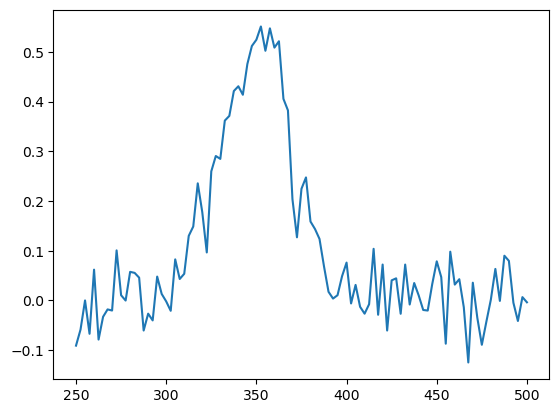

In [27]:
# Add code here
data = np.genfromtxt('noisy_spectrum.txt')
wavelength = data.T[0]
absorbance = data.T[1]
plt.plot(wavelength,absorbance)

Next we will need the function with which to fit our data.

*Complete the function for a Gaussian profile using the executable code below, where `xx` is the independent variable.  Be sure your arguments are ordered correctly to use with `curve_fit()`!*

In [28]:
# Complete the function
def gaussian(xx, amplitude, center, width):
    ygauss = amplitude*np.exp(-(xx-center)**2/(2*width)**2)
    return ygauss

*Now try calling curve_fit() using the Gaussian function and the spectral data.  What are the best-fit parameters?*

In [29]:
# Add code here
params, pcov = curve_fit(gaussian, wavelength, absorbance)
params

/tmp/ipykernel_83/2023997343.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  params, pcov = curve_fit(gaussian, wavelength, absorbance)


array([1., 1., 1.])

Hmm, this time it doesn't look so good.

A useful feature of `curve_fit` is that we can provide a "guess" of what we think the parameter values should be.  

This can help the algorithm converge when the fit is more challenging.  It is good practice to include when you use `curve_fit()`.

Try running `curve_fit()` again, this time adding the keyword argument `p0=[guess1,guess2]`.  The list contains our guesses for the free parameters in the same order as they are listed in the function, in this case: amplitude, center, width

In [30]:
# Add code here
params, pcov = curve_fit(gaussian, wavelength, absorbance, p0=[0.5,350,50])
params

array([  0.52433278, 350.02736523,  13.73065914])

Much better! Note that your guesses don't need to be perfect for this to work.

*Overplot the best-fit line on top of your measured data.*

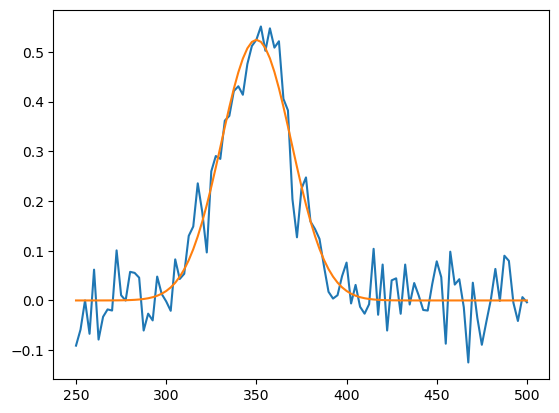

In [31]:
# Add code here
plt.plot(wavelength,absorbance)
y_fit = gaussian(wavelength, params[0], params[1], params[2])
plt.plot(wavelength, y_fit)

There are other features of `curve_fit()` that can come in handy if you have challenging data to fit.  This includes setting bounds on the values of the free parameters and adding an uncertainty specific to each value.  We won't go into detail here, but check out the documentation for more information.

Another important note is that our fitting will only describe the data as well as the function will allow it to!  If we use a bad model or equation, then no amount of parameter optimization will make it fit the data.

*Try fitting the `noisy_spectrum` data with your `line()` function instead.  Does it give a meaningful answer?*

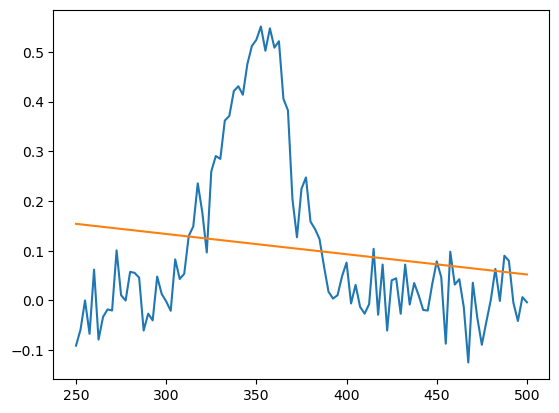

In [32]:
# Add code here
params, pcov = curve_fit(line, wavelength, absorbance)
y_fit = line(wavelength, params[0], params[1])
plt.plot(wavelength,absorbance)
plt.plot(wavelength, y_fit)

#### **Try it yourself**

Try loading in the file `rate.txt` and fitting the concentration curve to a first-order rate law: [A] = [A]_0 exp(-kt)

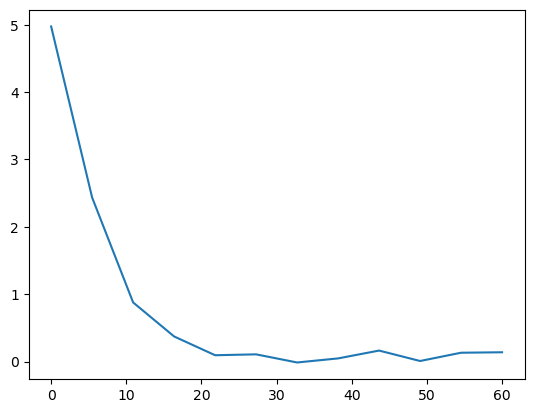

In [33]:
# Add code here
data = np.genfromtxt('rate.txt')
time=data.T[0]
conc=data.T[1]
plt.plot(time,conc)

[5.02256846 0.14769369]


/tmp/ipykernel_83/1303256128.py:2: RuntimeWarning: overflow encountered in exp
  A =A0*np.exp(-k*time)


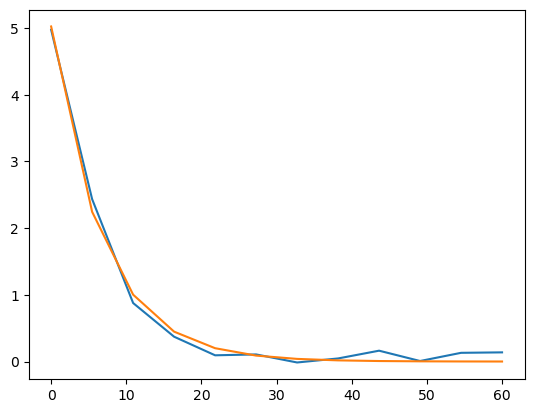

In [35]:
def first_order(time,A0,k):
    A =A0*np.exp(-k*time)
    return A

params, pcov = curve_fit(first_order,time,conc)
y_fit = first_order(time, params[0],params[1])
plt.plot(time,conc)
plt.plot(time,y_fit)
print(params)